<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [168]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 47.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 86.1MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [170]:
train_data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

In [171]:
train_data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


Посмотрите, какие типы данных представлены в нашем датасете

In [86]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [87]:
train_data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [172]:
categorical_cols = train_data.select_dtypes(include=['object']).columns
numerical_cols = train_data.select_dtypes(include=['number']).columns

print("Категориальные признаки:", categorical_cols)
print("Количественные признаки:", numerical_cols)

Категориальные признаки: Index(['name', 'title', 'culture', 'mother', 'father', 'heir', 'house',
       'spouse'],
      dtype='object')
Количественные признаки: Index(['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive'],
      dtype='object')


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [173]:
train_data.describe(include = ['int64', 'float64']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [174]:
nan_values = train_data.isnull().sum()
nan_values[nan_values > 0]

,0
title,840
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357
isAliveMother,1539
isAliveFather,1535


In [175]:
test_data = pd.read_csv('game_of_thrones_test.csv')

In [176]:
nan_test = test_data.isnull().sum()
nan_test[nan_test > 0]

,0
title,168
culture,200
dateOfBirth,235
mother,386
father,385
heir,387
house,46
spouse,313
isAliveMother,386
isAliveFather,385


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

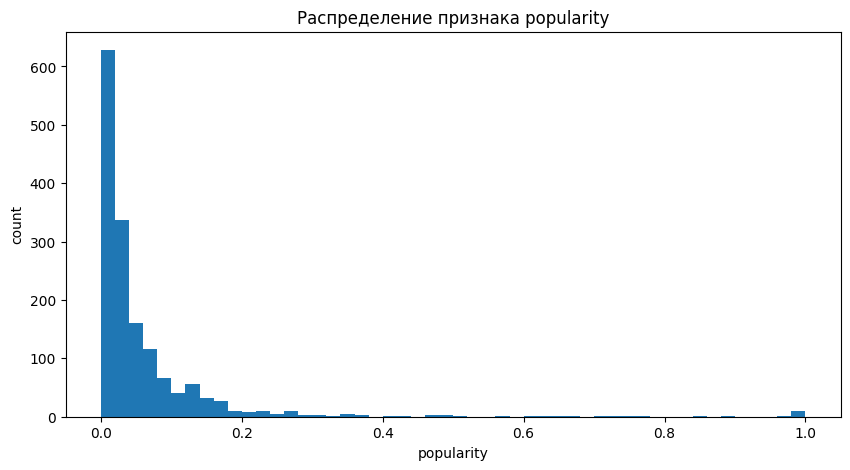

In [177]:
train_data.hist(column='popularity', bins=50, figsize=(10, 5), grid=False)
plt.xlabel('popularity')
plt.ylabel('count')
plt.title('Распределение признака popularity')
plt.show()

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


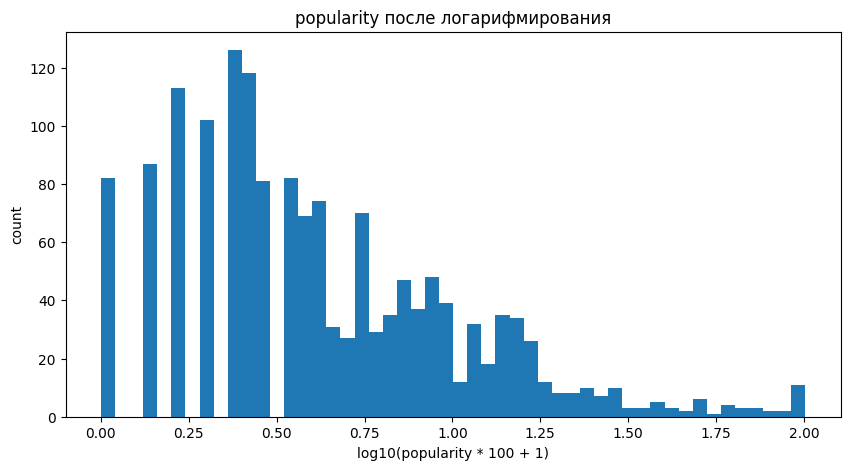

In [178]:
M = 100
train_data['popularity_log'] = np.log10(train_data['popularity'] * M + 1)

train_data['popularity_log'].hist(bins=50, figsize=(10, 5), grid=False)
plt.xlabel('log10(popularity * 100 + 1)')
plt.ylabel('count')
plt.title('popularity после логарифмирования')
plt.show()

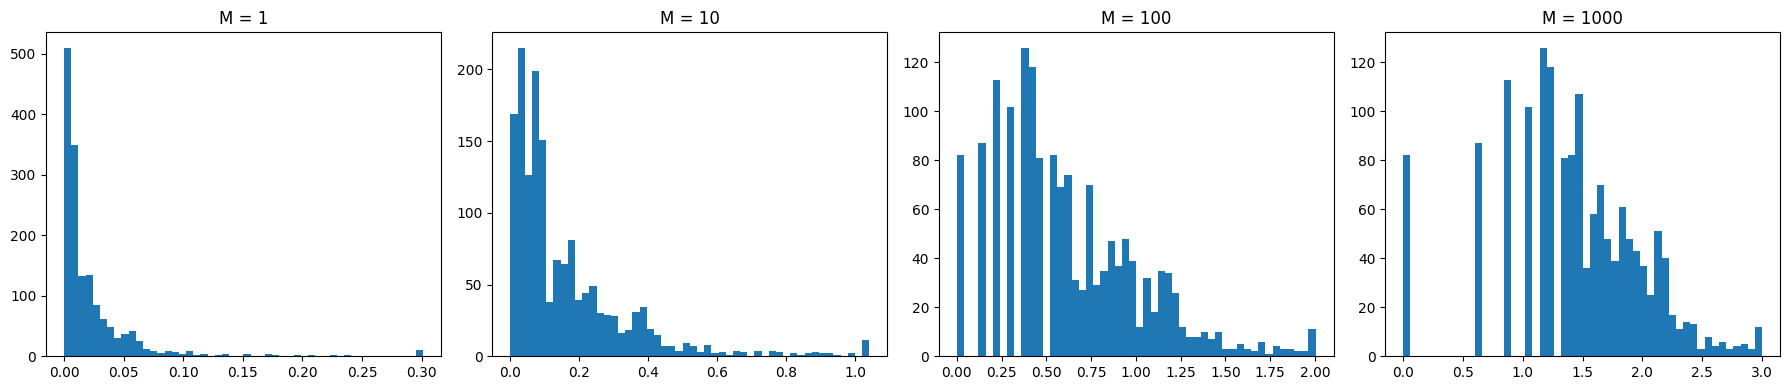

In [179]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, M in zip(axes, [1, 10, 100, 1000]):
    np.log10(train_data['popularity'] * M + 1).hist(bins=50, ax=ax, grid=False)
    ax.set_title(f'M = {M}')
plt.tight_layout()

In [180]:
for M in [1, 10, 50, 100, 500, 1000]:
    skew = np.log10(train_data['popularity'] * M + 1).skew()
    print(f'M={M:>5}: skew={skew:.3f}')

M=    1: skew=4.224
M=   10: skew=2.311
M=   50: skew=1.195
M=  100: skew=0.830
M=  500: skew=0.088
M= 1000: skew=-0.230


In [181]:
train_data.sample(n=5)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,popularity_log
S.No,,,,,,,,,,,,,,,,,,,,,
1127,Joffrey Lonmouth,Ser,1,NaN,99.0,NaN,NaN,NaN,House Lonmouth,NaN,...,NaN,NaN,NaN,0,1,15.0,0,0.023411,0,0.523894
1422,Uthor Tollett,Grey Glen,0,Valemen,NaN,NaN,NaN,NaN,House Tollett,NaN,...,NaN,NaN,NaN,0,1,NaN,0,0.010033,1,0.301756
317,Andrey Dalt,Ser,0,Dornish,NaN,NaN,NaN,NaN,House Dalt,NaN,...,NaN,NaN,NaN,0,1,NaN,0,0.036789,1,0.670147
1396,Todder,NaN,1,NaN,NaN,NaN,NaN,NaN,Night's Watch,NaN,...,NaN,NaN,NaN,0,0,NaN,0,0.036789,1,0.670147
936,Bhakaz zo Loraq,Cupbearer,1,Ghiscari,NaN,NaN,NaN,NaN,House of Loraq,NaN,...,NaN,NaN,NaN,0,1,NaN,0,0.003344,1,0.125302


В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

In [182]:
train_data['popularity_bin'] = pd.qcut(train_data['popularity'], q=4, labels=['low', 'medium', 'high', 'very_high'])
train_data['popularity_bin'].value_counts().sort_index()

,count
popularity_bin,
low,510
medium,281
high,382
very_high,384


In [183]:
pd.qcut(train_data['popularity'], q=4).value_counts().sort_index()

,count
popularity,
"(-0.001, 0.0134]",510
"(0.0134, 0.0234]",281
"(0.0234, 0.0635]",382
"(0.0635, 1.0]",384


In [184]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   name              1557 non-null   object  
 1   title             717 non-null    object  
 2   male              1557 non-null   int64   
 3   culture           488 non-null    object  
 4   dateOfBirth       279 non-null    float64 
 5   mother            18 non-null     object  
 6   father            22 non-null     object  
 7   heir              21 non-null     object  
 8   house             1176 non-null   object  
 9   spouse            200 non-null    object  
 10  book1             1557 non-null   int64   
 11  book2             1557 non-null   int64   
 12  book3             1557 non-null   int64   
 13  book4             1557 non-null   int64   
 14  book5             1557 non-null   int64   
 15  isAliveMother     18 non-null     float64 
 16  isAliveFather     22 non-null

In [185]:
# One-Hot Encoding
train_data = pd.get_dummies(
    train_data,
    columns=['popularity_bin'],
    prefix='popularity',
    dtype=int
)

In [186]:
train_data = train_data.drop(columns=['popularity', 'popularity_log'])

In [187]:
[c for c in train_data.columns if 'popularity' in c]
# ['popularity_low', 'popularity_medium', 'popularity_high', 'popularity_very_high']

['popularity_low',
 'popularity_medium',
 'popularity_high',
 'popularity_very_high']

In [188]:
test_data.head()

,S.No,name,title,male,culture,dateOfBirth,mother,father,heir,house,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
0,1558,Melissa Blackwood,NaN,0,NaN,156.0,NaN,NaN,NaN,House Blackwood,...,1,NaN,NaN,NaN,NaN,0,0,100.0,0,0.050167
1,1559,Melisandre,NaN,0,Asshai,NaN,NaN,NaN,NaN,R'hllor,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.745819
2,1560,Merrit,NaN,0,NaN,NaN,NaN,NaN,NaN,Brotherhood without banners,...,0,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033
3,1561,Meryn Trant,Ser,1,NaN,NaN,NaN,NaN,NaN,House Trant,...,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.220736
4,1562,Merrett Frey,NaN,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,...,1,NaN,NaN,NaN,1.0,1,0,38.0,0,0.434783


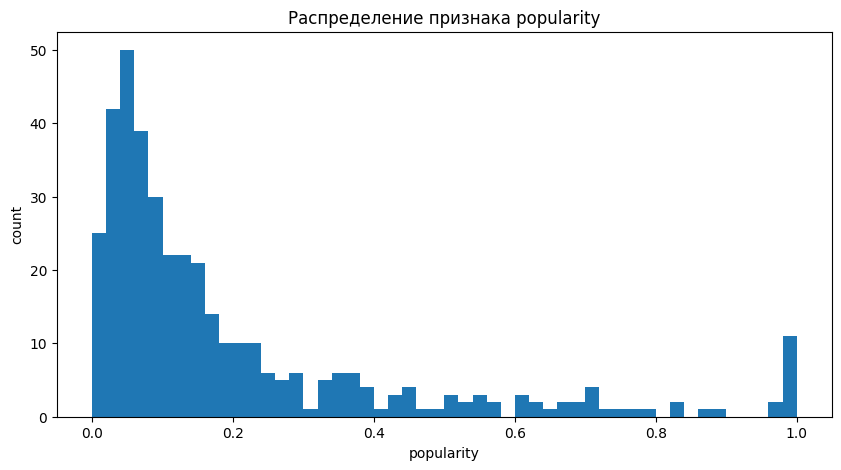

In [189]:
test_data.hist(column='popularity', bins=50, figsize=(10, 5), grid=False)
plt.xlabel('popularity')
plt.ylabel('count')
plt.title('Распределение признака popularity')
plt.show()

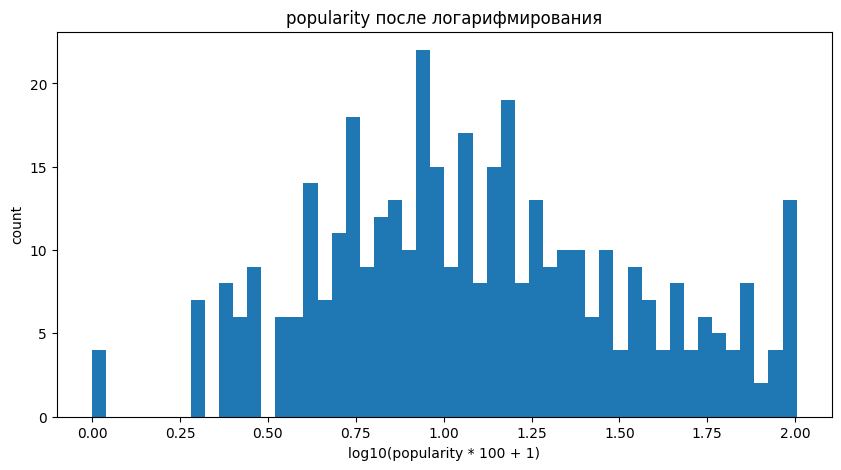

In [190]:
M = 100
test_data['popularity_log'] = np.log10(test_data['popularity'] * M + 1)

test_data['popularity_log'].hist(bins=50, figsize=(10, 5), grid=False)
plt.xlabel('log10(popularity * 100 + 1)')
plt.ylabel('count')
plt.title('popularity после логарифмирования')
plt.show()

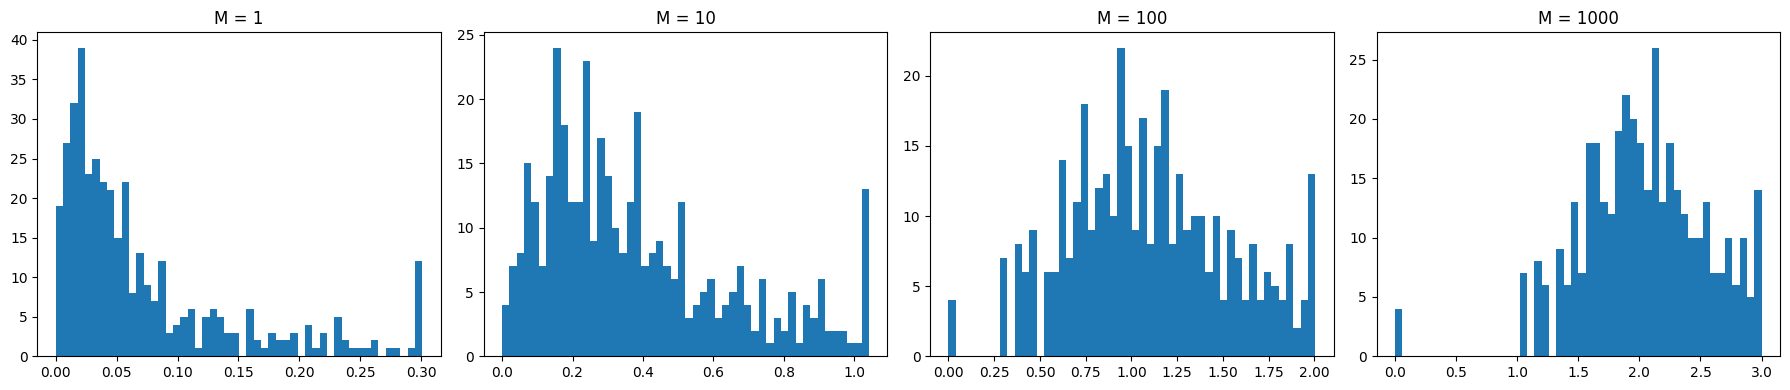

In [191]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, M in zip(axes, [1, 10, 100, 1000]):
    np.log10(test_data['popularity'] * M + 1).hist(bins=50, ax=ax, grid=False)
    ax.set_title(f'M = {M}')
plt.tight_layout()

In [192]:
for M in [1, 10, 50, 100, 500, 1000]:
    skew = np.log10(test_data['popularity'] * M + 1).skew()
    print(f'M={M:>5}: skew={skew:.3f}')

M=    1: skew=1.635
M=   10: skew=0.891
M=   50: skew=0.361
M=  100: skew=0.169
M=  500: skew=-0.254
M= 1000: skew=-0.466


In [193]:
test_data['popularity_bin'] = pd.qcut(test_data['popularity'], q=4, labels=['low', 'medium', 'high', 'very_high'])
test_data['popularity_bin'].value_counts().sort_index()

,count
popularity_bin,
low,105
medium,91
high,98
very_high,95


In [194]:
pd.qcut(test_data['popularity'], q=4).value_counts().sort_index()

,count
popularity,
"(-0.001, 0.0502]",105
"(0.0502, 0.104]",91
"(0.104, 0.231]",98
"(0.231, 1.0]",95


In [195]:
# One-Hot Encoding
test_data = pd.get_dummies(
    test_data,
    columns=['popularity_bin'],
    prefix='popularity',
    dtype=int
)

In [196]:
test_data = test_data.drop(columns=['popularity', 'popularity_log'])

In [197]:
[c for c in test_data.columns if 'popularity' in c]
# ['popularity_low', 'popularity_medium', 'popularity_high', 'popularity_very_high']

['popularity_low',
 'popularity_medium',
 'popularity_high',
 'popularity_very_high']

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [198]:
train_data['numDeadRelations'].value_counts().sort_index()

,count
numDeadRelations,
0,1488
1,24
2,4
3,4
4,7
5,10
6,3
7,7
8,2


In [199]:
# Создаем новый признак, проверяя условие, и сразу переводим True/False в 1/0
train_data['boolDeadRelations'] = (train_data['numDeadRelations'] > 0).astype(int)

# Если старый столбец numDeadRelations вам больше не нужен, его можно удалить:
train_data = train_data.drop(columns=['numDeadRelations'])

# Проверим результат
print(train_data['boolDeadRelations'].value_counts())

boolDeadRelations
0    1488
1      69
Name: count, dtype: int64


In [200]:
train_data.sample(n=5)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveSpouse,isMarried,isNoble,age,isAlive,popularity_low,popularity_medium,popularity_high,popularity_very_high,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
557,Guyne,Archmaester,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,1,NaN,1,1,0,0,0,0
1281,Pate of the Blue Fork,Ser,1,NaN,NaN,NaN,NaN,NaN,House Frey,Amerei Frey,...,1.0,1,1,NaN,0,0,0,0,1,0
1090,Harwood Stout,Goldgrass,1,Northmen,NaN,NaN,NaN,NaN,House Stout,NaN,...,NaN,0,1,NaN,1,0,0,1,0,0
555,Gulian Qorgyle,Ser,1,NaN,NaN,NaN,NaN,NaN,House Qorgyle,NaN,...,NaN,0,1,NaN,1,1,0,0,0,0
1139,Jorah Stark,King in the North,1,Northmen,NaN,NaN,NaN,NaN,House Stark,NaN,...,NaN,0,1,NaN,1,1,0,0,0,0


In [201]:
# Создаем новый признак, проверяя условие, и сразу переводим True/False в 1/0
test_data['boolDeadRelations'] = (test_data['numDeadRelations'] > 0).astype(int)

# Если старый столбец numDeadRelations вам больше не нужен, его можно удалить:
test_data = test_data.drop(columns=['numDeadRelations'])

# Проверим результат
print(test_data['boolDeadRelations'].value_counts())

boolDeadRelations
0    313
1     76
Name: count, dtype: int64


In [202]:
test_data.sample(n=5)

,S.No,name,title,male,culture,dateOfBirth,mother,father,heir,house,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,popularity_low,popularity_medium,popularity_high,popularity_very_high,boolDeadRelations
48,1606,Ralf Stonehouse,Red Jester,1,Ironborn,NaN,NaN,NaN,NaN,House Stonehouse,...,NaN,NaN,0,1,NaN,1,0,0,0,0
192,1750,Jon Snow,Lord Commander of the Night's Watch,1,Northmen,283.0,NaN,NaN,NaN,House Stark,...,NaN,NaN,0,1,22.0,0,0,0,1,1
279,1837,Shae,NaN,0,NaN,280.0,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,20.0,0,0,0,1,0
133,1691,Edmure Tully,Ser,1,Rivermen,267.0,NaN,NaN,NaN,House Tully,...,NaN,1.0,1,1,38.0,0,0,0,1,1
338,1896,Satin,NaN,1,NaN,280.0,NaN,NaN,NaN,Night's Watch,...,NaN,NaN,0,0,25.0,0,1,0,0,0


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [203]:
train_data['age'].describe()

,age
count,279.000000
mean,35.290323
std,26.364864
min,0.000000
25%,16.000000
50%,24.000000
75%,49.000000
max,100.000000


In [204]:
train_data['age_value'] = train_data['age'].fillna(0)
train_data['age_no_data'] = [1 if np.isnan(x) else 0 for x in train_data['age']]

# (Опционально) Удаляем старый столбец age, так как мы извлекли из него всю информацию
# train_data = train_data.drop(columns=['age'])

In [205]:
test_data['age_value'] = test_data['age'].fillna(0)
test_data['age_no_data'] = [1 if np.isnan(x) else 0 for x in test_data['age']]

In [206]:
train_data = train_data.drop(columns=['age'])

In [207]:
test_data = test_data.drop(columns=['age'])

In [208]:
train_data.sample(n=5)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isMarried,isNoble,isAlive,popularity_low,popularity_medium,popularity_high,popularity_very_high,boolDeadRelations,age_value,age_no_data
S.No,,,,,,,,,,,,,,,,,,,,,
785,Morgarth,Ser,1,NaN,NaN,NaN,NaN,NaN,House Baelish,NaN,...,0,1,1,0,1,0,0,0,0.0,1
445,Damon Lannister (son of Jason),NaN,1,NaN,244.0,NaN,NaN,NaN,House Lannister,Ella Lannister,...,1,0,1,0,0,1,0,0,61.0,0
731,Lymond Mallister,Seagard,0,NaN,NaN,NaN,NaN,NaN,House Mallister,NaN,...,0,1,1,1,0,0,0,0,0.0,1
781,Mollander,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,1,0,0,1,0,0,0.0,1
1427,Viserys Plumm,Lord,0,NaN,176.0,NaN,NaN,NaN,House Plumm,NaN,...,0,1,0,0,0,0,1,0,100.0,0


In [209]:
test_data.sample(n=5)

,S.No,name,title,male,culture,dateOfBirth,mother,father,heir,house,...,isAliveSpouse,isMarried,isNoble,popularity_low,popularity_medium,popularity_high,popularity_very_high,boolDeadRelations,age_value,age_no_data
256,1814,Rickard Karstark,Karhold,1,Northmen,NaN,NaN,NaN,NaN,House Karstark,...,NaN,0,1,0,0,1,0,1,0.0,1
150,1708,Gerold Dayne,Ser,1,Dorne,270.0,NaN,NaN,NaN,House Dayne of High Hermitage,...,NaN,0,1,0,0,1,0,0,35.0,0
325,1883,Quaithe,NaN,0,Asshai'i,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,1,0,0,0.0,1
291,1849,Tyland Lannister,Ser,1,NaN,NaN,NaN,NaN,NaN,House Lannister,...,NaN,0,1,0,0,0,1,0,0.0,1
248,1806,Wylis Manderly,Ser,1,NaN,252.0,NaN,NaN,NaN,House Manderly,...,NaN,0,1,0,0,1,0,0,53.0,0


Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

In [210]:
# Заполняем пропуски в dateOfBirth нулями (как мы делали с age_value)
train_data['dateOfBirth_value'] = train_data['dateOfBirth'].fillna(0)

# Признак dateOfBirth_no_data мы НЕ создаем, так как он полностью дублирует age_no_data.

# Удаляем исходный признак dateOfBirth за ненадобностью
train_data = train_data.drop(columns=['dateOfBirth'])

# Для проверки можно посмотреть, что осталось
train_data[['age_value', 'age_no_data', 'dateOfBirth_value']].head()

,age_value,age_no_data,dateOfBirth_value
S.No,,,
1,0.0,1,0.0
2,97.0,0,208.0
3,0.0,1,0.0
4,23.0,0,82.0
5,29.0,0,276.0


In [211]:
# Заполняем пропуски в dateOfBirth нулями (как мы делали с age_value)
test_data['dateOfBirth_value'] = test_data['dateOfBirth'].fillna(0)

# Признак dateOfBirth_no_data мы НЕ создаем, так как он полностью дублирует age_no_data.

# Удаляем исходный признак dateOfBirth за ненадобностью
test_data = test_data.drop(columns=['dateOfBirth'])

# Для проверки можно посмотреть, что осталось
test_data[['age_value', 'age_no_data', 'dateOfBirth_value']].head()

,age_value,age_no_data,dateOfBirth_value
0,100.0,0,156.0
1,0.0,1,0.0
2,0.0,1,0.0
3,0.0,1,0.0
4,38.0,0,262.0


**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [212]:
train_data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [213]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [214]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [131]:
culture_no_data = {v: k for k, values in cultures_grouped.items() for v in values}

In [215]:
culture_no_data

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

In [216]:
train_data.sample(n=5)

,name,title,male,culture,mother,father,heir,house,spouse,book1,...,isNoble,isAlive,popularity_low,popularity_medium,popularity_high,popularity_very_high,boolDeadRelations,age_value,age_no_data,dateOfBirth_value
S.No,,,,,,,,,,,,,,,,,,,,,
885,Alesander Frey,NaN,0,NaN,NaN,NaN,NaN,House Frey,NaN,0,...,0,1,0,0,0,1,0,40.0,0,265.0
1525,Jasper Wylde,Rain House,1,NaN,NaN,NaN,NaN,House Wylde,NaN,0,...,1,0,0,0,0,1,0,0.0,1,0.0
905,Andar Royce,Ser,1,Valemen,NaN,NaN,NaN,House Royce,NaN,1,...,1,1,0,0,1,0,0,0.0,1,0.0
1151,Kyra,NaN,1,NaN,NaN,NaN,NaN,House Stark,NaN,1,...,0,0,0,0,1,0,0,20.0,0,280.0
1362,Shierle Swyft,NaN,0,NaN,NaN,NaN,NaN,House Swyft,Melwyn Sarsfield,0,...,0,1,0,0,1,0,0,0.0,1,0.0


In [217]:
train_data['cultures_grouped'] = train_data['culture'].fillna('culture_no_data')
test_data['cultures_grouped']  = test_data['culture'].fillna('culture_no_data')

In [218]:
train_data.columns

Index(['name', 'title', 'male', 'culture', 'mother', 'father', 'heir', 'house',
       'spouse', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother',
       'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble',
       'isAlive', 'popularity_low', 'popularity_medium', 'popularity_high',
       'popularity_very_high', 'boolDeadRelations', 'age_value', 'age_no_data',
       'dateOfBirth_value', 'cultures_grouped'],
      dtype='object')

In [219]:
print(train_data['culture'].isna().sum())
print(train_data['cultures_grouped'].isna().sum())

# что именно не смапилось
mask = train_data['culture'].notna() & train_data['cultures_grouped'].isna()
train_data.loc[mask, 'culture'].unique()

1069
0


array([], dtype=object)

In [220]:
mask = test_data['culture'].notna() & test_data['cultures_grouped'].isna()
test_data.loc[mask, 'culture'].unique()

array([], dtype=object)

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [221]:
train_data['cultures_grouped'].isna().sum()

np.int64(0)

In [222]:
train_data['cultures_grouped'].isna().sum()   # 0
train_data['cultures_grouped'].value_counts()

,count
cultures_grouped,
culture_no_data,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


In [223]:
# 1. Берем столбец culture, переводим в нижний регистр (str.lower)
# 2. Применяем наш инвертированный словарь (у вас он назван culture_no_data)
# 3. Все оставшиеся пропуски заполняем строкой 'culture_no_data'
train_data['cultures_grouped'] = train_data['culture'].str.lower().map(culture_no_data).fillna('culture_no_data')

# Обязательно делаем то же самое для тестовой выборки!
test_data['cultures_grouped'] = test_data['culture'].str.lower().map(culture_no_data).fillna('culture_no_data')

# Теперь проверим, что пустых значений не осталось и посмотрим на распределение
print("Пропусков:", train_data['cultures_grouped'].isna().sum())
train_data['cultures_grouped'].value_counts()

Пропусков: 0


,count
cultures_grouped,
culture_no_data,1069
Essos Nations,109
the North,108
the Iron Islands,95
Other Nations,57
Old Nations,32
the Mountain and the Vale,25
Dorne,21
the Rock,14


In [224]:
train_data.isna().sum().loc[lambda s: s > 0]

,0
title,840
culture,1069
mother,1539
father,1535
heir,1536
house,381
spouse,1357
isAliveMother,1539
isAliveFather,1535
isAliveHeir,1536


In [225]:
test_data.isna().sum().loc[lambda s: s > 0]

,0
title,168
culture,200
mother,386
father,385
heir,387
house,46
spouse,313
isAliveMother,386
isAliveFather,385
isAliveHeir,387


Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

In [226]:
THRESHOLD = 20
freq = train_data['cultures_grouped'].value_counts()
rare = freq[freq < THRESHOLD].index          # Rock, Reach, Isles and Rivers, Stormlands

for df in (train_data, test_data):
    df['cultures_grouped'] = df['cultures_grouped'].where(
        ~df['cultures_grouped'].isin(rare), 'Other Nations'
    )

In [227]:
train_data = pd.get_dummies(train_data, columns=['cultures_grouped'], prefix='culture', dtype=int)
train_data = train_data.drop(columns=['culture'], errors='ignore')

In [228]:
test_data = pd.get_dummies(test_data, columns=['cultures_grouped'], prefix='culture', dtype=int)
test_data = test_data.drop(columns=['culture'], errors='ignore')

In [229]:
train_data.sample(n=5)

,name,title,male,mother,father,heir,house,spouse,book1,book2,...,age_no_data,dateOfBirth_value,culture_Dorne,culture_Essos Nations,culture_Old Nations,culture_Other Nations,culture_culture_no_data,culture_the Iron Islands,culture_the Mountain and the Vale,culture_the North
S.No,,,,,,,,,,,,,,,,,,,,,
1052,Garth Tyrell,Lord Seneschal,1,NaN,NaN,NaN,House Tyrell,NaN,1,1,...,1,0.0,0,0,0,0,1,0,0,0
1057,Gerardys,Grand Maester,1,NaN,NaN,NaN,Blacks,NaN,0,0,...,1,0.0,0,0,0,0,1,0,0,0
620,Jaggot,NaN,0,NaN,NaN,NaN,Stone Crows,NaN,1,0,...,1,0.0,0,0,0,0,0,0,1,0
35,Xhondo,NaN,1,NaN,NaN,NaN,NaN,NaN,0,0,...,1,0.0,0,1,0,0,0,0,0,0
819,Old Crackbones,NaN,1,NaN,NaN,NaN,NaN,NaN,0,0,...,1,0.0,0,0,0,0,1,0,0,0


In [230]:
test_data.sample(n=5)

,S.No,name,title,male,mother,father,heir,house,spouse,book1,...,age_no_data,dateOfBirth_value,culture_Dorne,culture_Essos Nations,culture_Old Nations,culture_Other Nations,culture_culture_no_data,culture_the Iron Islands,culture_the Mountain and the Vale,culture_the North
288,1846,Torrhen Karstark,NaN,1,NaN,NaN,NaN,House Karstark,NaN,1,...,1,0.0,0,0,0,0,0,0,0,1
286,1844,Rolland Storm,Ser,1,NaN,NaN,NaN,House Caron,NaN,0,...,1,0.0,0,0,0,0,1,0,0,0
83,1641,Ashara Dayne,NaN,0,NaN,NaN,NaN,House Dayne,NaN,1,...,1,0.0,0,0,0,0,1,0,0,0
191,1749,Kedry,Maester,1,NaN,NaN,NaN,NaN,NaN,0,...,1,0.0,0,0,0,0,1,0,0,0
378,1936,Gormond Goodbrother,NaN,1,NaN,NaN,NaN,House Goodbrother,NaN,0,...,0,282.0,0,0,0,0,0,1,0,0


**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [231]:
# Количество уникальнх значений в каждом столбце
train_data.nunique()

,0
name,1557
title,195
male,2
mother,16
father,19
heir,20
house,315
spouse,186
book1,2
book2,2


In [254]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
train_data.describe(include=[np.number]).T[
    ['count', 'min', 'max']
].assign(
    N_unique_values=train_data.nunique(),
    N_NaN=train_data.isna().sum()
)

,count,min,max,N_unique_values,N_NaN
male,1557.0,0.0,1.0,2,0
book1,1557.0,0.0,1.0,2,0
book2,1557.0,0.0,1.0,2,0
book3,1557.0,0.0,1.0,2,0
book4,1557.0,0.0,1.0,2,0
...,...,...,...,...,...
house_night's watch,1557.0,0.0,1.0,2,0
house_other,1557.0,0.0,1.0,2,0
house_second sons,1557.0,0.0,1.0,2,0
house_stone crows,1557.0,0.0,1.0,2,0


In [253]:
test_data.describe(include=[np.number]).T[
    ['count', 'min', 'max']
].assign(
    N_unique_values=test_data.nunique(),
    N_NaN=test_data.isna().sum()
)

,count,min,max,N_unique_values,N_NaN
S.No,389.0,1558.0,1946.0,389,0
male,389.0,0.0,1.0,2,0
book1,389.0,0.0,1.0,2,0
book2,389.0,0.0,1.0,2,0
book3,389.0,0.0,1.0,2,0
...,...,...,...,...,...
house_house whent,389.0,0.0,1.0,2,0
house_night's watch,389.0,0.0,1.0,2,0
house_other,389.0,0.0,1.0,2,0
house_stone crows,389.0,0.0,1.0,2,0


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [69]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

# data.groupby('НАЗВАНИЕ ПРИЗНАКА', dropna = False)['isAlive'].mean()
# pd.pivot_table(data = data, values = 'isAlive', index = 'НАЗВАНИЕ ПРИЗНАКА', aggfunc=['mean', 'count'], dropna=False)

In [234]:
features = [
    'isAliveMother',
    'isAliveFather',
    'isAliveHeir',
    'isAliveSpouse'
]

for feature in features:
    print(f'\n===== {feature} =====')
    
    display(
        pd.pivot_table(
            data=train_data,
            values='isAlive',
            index=feature,
            aggfunc=['mean', 'count'],
            dropna=False
        )
    )


===== isAliveMother =====


,mean,count
,isAlive,isAlive
isAliveMother,,
0.0,0.166667,6
1.0,0.166667,12
NaN,0.785575,1539



===== isAliveFather =====


,mean,count
,isAlive,isAlive
isAliveFather,,
0.0,0.235294,17
1.0,0.400000,5
NaN,0.785668,1535



===== isAliveHeir =====


,mean,count
,isAlive,isAlive
isAliveHeir,,
0.0,0.000000,7
1.0,0.357143,14
NaN,0.785807,1536



===== isAliveSpouse =====


,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


In [235]:
features = [
    'isAliveMother',
    'isAliveFather',
    'isAliveHeir',
    'isAliveSpouse'
]

# Заполняем пропуски отдельной категорией
train_data[features] = train_data[features].fillna('no_data')

# One-Hot Encoding
train_data = pd.get_dummies(
    train_data,
    columns=features,
    prefix=features,
    dtype=int
)

In [236]:
features = [
    'isAliveMother',
    'isAliveFather',
    'isAliveHeir',
    'isAliveSpouse'
]

# Заполняем пропуски отдельной категорией
test_data[features] = test_data[features].fillna('no_data')

# One-Hot Encoding
test_data = pd.get_dummies(
    test_data,
    columns=features,
    prefix=features,
    dtype=int
)

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [237]:
numeric_features = train_data.select_dtypes(
    include=np.number
).columns

numeric_features

Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isAlive', 'popularity_low', 'popularity_medium',
       'popularity_high', 'popularity_very_high', 'boolDeadRelations',
       'age_value', 'age_no_data', 'dateOfBirth_value', 'culture_Dorne',
       'culture_Essos Nations', 'culture_Old Nations', 'culture_Other Nations',
       'culture_culture_no_data', 'culture_the Iron Islands',
       'culture_the Mountain and the Vale', 'culture_the North',
       'isAliveMother_0.0', 'isAliveMother_1.0', 'isAliveMother_no_data',
       'isAliveFather_0.0', 'isAliveFather_1.0', 'isAliveFather_no_data',
       'isAliveHeir_0.0', 'isAliveHeir_1.0', 'isAliveHeir_no_data',
       'isAliveSpouse_0.0', 'isAliveSpouse_1.0', 'isAliveSpouse_no_data'],
      dtype='object')

In [238]:
train_data = train_data.drop(
    columns=['dateOfBirth_value'],
    errors='ignore'
)

test_data = test_data.drop(
    columns=['dateOfBirth_value'],
    errors='ignore'
)

In [239]:
train_data[numeric_features].head()

KeyError: "['dateOfBirth_value'] not in index"

In [240]:
categorical_cols = train_data.select_dtypes(include=['object']).columns
numerical_cols = train_data.select_dtypes(include=['number']).columns

print("Категориальные признаки:", categorical_cols)
print("Количественные признаки:", numerical_cols)

Категориальные признаки: Index(['name', 'title', 'mother', 'father', 'heir', 'house', 'spouse'], dtype='object')
Количественные признаки: Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isAlive', 'popularity_low', 'popularity_medium',
       'popularity_high', 'popularity_very_high', 'boolDeadRelations',
       'age_value', 'age_no_data', 'culture_Dorne', 'culture_Essos Nations',
       'culture_Old Nations', 'culture_Other Nations',
       'culture_culture_no_data', 'culture_the Iron Islands',
       'culture_the Mountain and the Vale', 'culture_the North',
       'isAliveMother_0.0', 'isAliveMother_1.0', 'isAliveMother_no_data',
       'isAliveFather_0.0', 'isAliveFather_1.0', 'isAliveFather_no_data',
       'isAliveHeir_0.0', 'isAliveHeir_1.0', 'isAliveHeir_no_data',
       'isAliveSpouse_0.0', 'isAliveSpouse_1.0', 'isAliveSpouse_no_data'],
      dtype='object')


In [241]:
train_data[categorical_cols].head()

,name,title,mother,father,heir,house,spouse
S.No,,,,,,,
1,Viserys II Targaryen,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN
2,Walder Frey,Lord of the Crossing,NaN,NaN,NaN,House Frey,Perra Royce
3,Addison Hill,Ser,NaN,NaN,NaN,House Swyft,NaN
4,Aemma Arryn,Queen,NaN,NaN,NaN,House Arryn,Viserys I Targaryen
5,Sylva Santagar,Greenstone,NaN,NaN,NaN,House Santagar,Eldon Estermont


In [ ]:
# 1. Удаляем столбцы с уникальными именами
cols_to_drop = ['name', 'mother', 'father', 'heir', 'spouse']
train_data = train_data.drop(columns=cols_to_drop, errors='ignore')
test_data = test_data.drop(columns=cols_to_drop, errors='ignore')

# 2. Выделяем категориальные признаки и заполняем пропуски
cat_cols = ['title', 'house']
train_data[cat_cols] = train_data[cat_cols].fillna('Unknown')
test_data[cat_cols] = test_data[cat_cols].fillna('Unknown')

# 2. Приводим всё к нижнему регистру и отрезаем случайные пробелы по краям
for col in cat_cols:
    train_data[col] = train_data[col].str.lower().str.strip()
    test_data[col] = test_data[col].str.lower().str.strip()

In [247]:
categorical_cols = train_data.select_dtypes(include=['object']).columns
numerical_cols = train_data.select_dtypes(include=['number']).columns

print("Категориальные признаки:", categorical_cols)
print("Количественные признаки:", numerical_cols)

Категориальные признаки: Index(['title', 'house'], dtype='object')
Количественные признаки: Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isAlive', 'popularity_low', 'popularity_medium',
       'popularity_high', 'popularity_very_high', 'boolDeadRelations',
       'age_value', 'age_no_data', 'culture_Dorne', 'culture_Essos Nations',
       'culture_Old Nations', 'culture_Other Nations',
       'culture_culture_no_data', 'culture_the Iron Islands',
       'culture_the Mountain and the Vale', 'culture_the North',
       'isAliveMother_0.0', 'isAliveMother_1.0', 'isAliveMother_no_data',
       'isAliveFather_0.0', 'isAliveFather_1.0', 'isAliveFather_no_data',
       'isAliveHeir_0.0', 'isAliveHeir_1.0', 'isAliveHeir_no_data',
       'isAliveSpouse_0.0', 'isAliveSpouse_1.0', 'isAliveSpouse_no_data'],
      dtype='object')


In [248]:
# Смотрим топ-20 самых частых титулов
print("=== Топ-20 значений 'title' ===")
print(train_data['title'].value_counts().head(20))

print("\n" + "-"*30 + "\n")

# Смотрим топ-20 самых частых домов
print("=== Топ-20 значений 'house' ===")
print(train_data['house'].value_counts().head(20))

print("\n" + "-"*30 + "\n")

# А теперь посмотрим на "хвост" - сколько значений встречаются ровно 1 раз
title_counts = train_data['title'].value_counts()
house_counts = train_data['house'].value_counts()

print(f"Титулов, встречающихся 1 раз: {(title_counts == 1).sum()}")
print(f"Домов, встречающихся 1 раз: {(house_counts == 1).sum()}")

=== Топ-20 значений 'title' ===
title
unknown                                840
ser                                    306
maester                                 29
archmaester                             21
lord                                    19
septon                                  16
winterfell                              15
lady                                    10
septa                                    9
princess                                 9
king in the north                        9
cupbearer                                8
lord commander of the night's watch      8
prince                                   7
grand maester                            6
wisdom                                   5
khal                                     5
king-beyond-the-wall                     4
prince of dragonstone                    4
eyrie                                    3
Name: count, dtype: int64

------------------------------

=== Топ-20 значений 'house' ===
house
unkno

In [249]:
# Задаем порог отсечения: значения, встречающиеся реже 5 раз, станут 'other'
threshold = 5

for col in ['title', 'house']:
    # Считаем частоты только по обучающей выборке! (чтобы не было утечки данных)
    freq = train_data[col].value_counts()
    
    # Собираем список "популярных" значений, которые преодолели порог
    popular_values = freq[freq >= threshold].index
    
    # В train_data: оставляем значение, если оно в списке популярных, иначе меняем на 'other'
    train_data[col] = train_data[col].where(train_data[col].isin(popular_values), 'other')
    
    # В test_data: делаем то же самое, ориентируясь на список популярных значений из train
    test_data[col] = test_data[col].where(test_data[col].isin(popular_values), 'other')

# Посмотрим, насколько сократилось количество уникальных категорий
print(f"Уникальных титулов теперь: {train_data['title'].nunique()}")
print(f"Уникальных домов теперь: {train_data['house'].nunique()}")

Уникальных титулов теперь: 18
Уникальных домов теперь: 58


In [250]:
# # 3. Применяем One-Hot Encoding к обучающей и тестовой выборкам
train_data = pd.get_dummies(train_data, columns=cat_cols, dtype=int)
test_data = pd.get_dummies(test_data, columns=cat_cols, dtype=int)

In [251]:
categorical_cols = train_data.select_dtypes(include=['object']).columns
numerical_cols = train_data.select_dtypes(include=['number']).columns

print("Категориальные признаки:", categorical_cols)
print("Количественные признаки:", numerical_cols)

Категориальные признаки: Index([], dtype='object')
Количественные признаки: Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isAlive', 'popularity_low',
       ...
       'house_house webber', 'house_house westerling', 'house_house whent',
       'house_house wylde', 'house_kingsguard', 'house_night's watch',
       'house_other', 'house_second sons', 'house_stone crows',
       'house_unknown'],
      dtype='object', length=112)


In [252]:
from sklearn.preprocessing import StandardScaler

# Инициализируем скейлер
scaler = StandardScaler()

# ОБУЧАЕМ скейлер только на тренировочных данных и сразу преобразуем их
# Внимание: передаем ['age_value'] в двойных скобках, так как scaler ожидает двумерный массив (DataFrame)
train_data['age_value'] = scaler.fit_transform(train_data[['age_value']])

# Для тестовых данных делаем ТОЛЬКО transform, чтобы не было утечки данных
test_data['age_value'] = scaler.transform(test_data[['age_value']])

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [256]:
X = train_data.drop(columns=['isAlive'])
y = train_data['isAlive']

In [257]:
print('X:', X.shape)
print('y:', y.shape)

X: (1557, 111)
y: (1557,)


In [258]:
X.columns

Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'popularity_low', 'popularity_medium',
       ...
       'house_house webber', 'house_house westerling', 'house_house whent',
       'house_house wylde', 'house_kingsguard', 'house_night's watch',
       'house_other', 'house_second sons', 'house_stone crows',
       'house_unknown'],
      dtype='object', length=111)

In [259]:
y.head()

,isAlive
S.No,
1,0
2,1
3,1
4,0
5,1


**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [267]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [268]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1245, 111)
X_test: (312, 111)
y_train: (1245,)
y_test: (312,)


## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [265]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [266]:
predictions = {}

logistic_regression = LogisticRegression(C=1, max_iter=1000, solver='saga')
ada_boost = AdaBoostClassifier()
random_forest = RandomForestClassifier()
gaussian_process = GaussianProcessClassifier()
gaussian_nb = GaussianNB()
knn = KNeighborsClassifier()
svc = SVC()
decision_tree = DecisionTreeClassifier()

models = {
    'LogisticRegression': logistic_regression,
    'AdaBoost': ada_boost,
    'Random Forest': random_forest,
    'Gaussian Process': gaussian_process,
    'GaussianNB': gaussian_nb,
    'KNeighbors': knn,
    'SVC': svc,
    'Decision Tree': decision_tree
}

In [269]:
for model_name, model in models.items():
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [270]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [271]:
# Шаг 3. Предсказание на тестовых данных

# ваш код здесь
accuracy_results = {}

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[model_name] = accuracy

print(accuracy_results)
# Шаг 4. Оценка предсказания по метрике accuracy
best_model = max(accuracy_results, key=accuracy_results.get)
print(f'Лучшая модель: {best_model} с accuracy = {accuracy_results[best_model]}')

{'LogisticRegression': 0.8141025641025641, 'AdaBoost': 0.7980769230769231, 'Random Forest': 0.7884615384615384, 'Gaussian Process': 0.7916666666666666, 'GaussianNB': 0.3301282051282051, 'KNeighbors': 0.8012820512820513, 'SVC': 0.8141025641025641, 'Decision Tree': 0.7756410256410257}
Лучшая модель: LogisticRegression с accuracy = 0.8141025641025641


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [275]:
test_data.sample(n=5)

,S.No,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity_low,...,house_house tyrell,house_house umber,house_house velaryon,house_house webber,house_house westerling,house_house whent,house_night's watch,house_other,house_stone crows,house_unknown
266,1824,0,0,0,1,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
201,1759,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
34,1592,1,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
383,1941,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
127,1685,0,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [276]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 10.3MB/s]


In [277]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [278]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [279]:
submission.to_csv("/content/new_submission.csv", index=False)

In [281]:
# 1. Получаем точный список признаков, на которых обучалась модель
expected_features = model.feature_names_in_

# 2. Выравниваем тестовый датасет по этому списку
# (лишнее удалится, недостающее заполнится нулями)
X_test_final = test_data.reindex(columns=expected_features, fill_value=0)

# 3. Теперь смело делаем предсказания
test_predictions = model.predict(X_test_final)

# 4. Подставляем полученные предсказания в датафрейм submission
submission['isAlive'] = test_predictions

# 5. Сохраняем итоговый файл
submission.to_csv("/content/submission.csv")

# Проверяем результат
submission.head()

,isAlive
S.No,
1558,0
1559,1
1560,1
1561,1
1562,1


In [288]:
# Сохраняем заполненный датафрейм в файл
# Если S.No у вас задан как индекс (index_col='S.No'), он автоматически сохранится в файл
# Пример того, как должен выглядеть ваш код. Подставьте свой скопированный путь:
submission.to_csv(r'D:\dev_proj\deeplearning\machine_learning\submission.csv')

In [287]:
import os
print(os.getcwd())

/content


In [289]:
from google.colab import files
files.download('/content/submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>